## Step 0: Load BTCC Treasury Data

Load Bitcoin Treasury Company (BTCC) treasury financial data from `btcc_data.json`.
- ASST = BTCC common stock ticker
- SATA = BTCC preferred stock ticker
- Data is fetched by running `python fetch_data.py`


In [48]:
# ============================================================================
# LOAD BTCC TREASURY DATA FROM JSON
# ASST = BTCC common stock ticker
# SATA = BTCC preferred stock ticker
# Data is fetched by running: python fetch_data.py
# ============================================================================

import json
import os

btcc_data_file = 'output/btcc_data.json'

if os.path.exists(btcc_data_file):
    try:
        with open(btcc_data_file, 'r') as f:
            strive_data = json.load(f)
        
        print(f"✓ Loaded BTCC data from {btcc_data_file}")
        if 'timestamp' in strive_data:
            print(f"  Data timestamp: {strive_data['timestamp']}")
        
        # Print loaded data summary
        if 'bitcoin_holdings' in strive_data:
            print(f"  ✓ BTCC Bitcoin holdings: {strive_data['bitcoin_holdings']:,.2f} BTC")
        if 'cash' in strive_data:
            print(f"  ✓ BTCC cash reserve: ${strive_data['cash']:,.0f}")
        if 'sata_shares' in strive_data:
            print(f"  ✓ SATA (preferred) shares outstanding: {strive_data['sata_shares']:,}")
        if 'sata_dividend_rate' in strive_data:
            print(f"  ✓ SATA (preferred) dividend rate: {strive_data['sata_dividend_rate']:.2%}")
        if 'sata_current_price' in strive_data and strive_data['sata_current_price']:
            print(f"  ✓ SATA current price: ${strive_data['sata_current_price']:,.2f}")
        
    except Exception as e:
        print(f"⚠ Error loading {btcc_data_file}: {e}")
        print(f"  Using default values - please run 'python fetch_data.py' to fetch latest data.")
        strive_data = {}
else:
    print(f"⚠ {btcc_data_file} not found. Using default values.")
    print(f"  Run: python fetch_data.py to fetch latest data.")
    strive_data = {}


✓ Loaded BTCC data from btcc_data.json
  Data timestamp: 2025-12-17T02:47:02.516261
  ✓ BTCC Bitcoin holdings: 7,525.02 BTC
  ✓ BTCC cash reserve: $109,069,000
  ✓ SATA (preferred) shares outstanding: 2,000,000
  ✓ SATA (preferred) dividend rate: 12.25%
  ✓ SATA current price: $91.51


# SATA Preferred Equity Valuation Model

This notebook values SATA preferred stock by discounting future dividends, where dividends are funded by Bitcoin sales after cash reserves are depleted. Bitcoin price paths are loaded from `btc_price_paths.json`, which is generated by `btc_price_paths.ipynb` using a manual normal-based distribution with adjustable parameters.


In [49]:
# ============================================================================
# CONFIGURATION SECTION - ALL ADJUSTABLE PARAMETERS
# ============================================================================

# ----------------------------------------------------------------------------
# Simulation Parameters
# ----------------------------------------------------------------------------
NUM_SIMULATIONS = 10000          # Number of Monte Carlo simulation runs
SIMULATION_YEARS = 100           # Projection period in years
MEAN_CAGR = 0.0                  # Mean Compound Annual Growth Rate (Bitcoin trends to zero)

# ----------------------------------------------------------------------------
# SATA Preferred Stock Parameters
# ----------------------------------------------------------------------------
# Use fetched data if available, otherwise use defaults
SATA_SHARES_OUTSTANDING = strive_data.get('sata_shares', 10000000)  # Total SATA shares outstanding (update with actual value)
SATA_ANNUAL_DIVIDEND_RATE = strive_data.get('sata_dividend_rate', 0.10)  # Annual dividend rate (update with actual value)
SATA_PAR_VALUE = 100                  # Par value per share in USD ($100)

# Calculate total SATA dividend obligations
SATA_MONTHLY_DIVIDEND_PER_SHARE = SATA_ANNUAL_DIVIDEND_RATE * SATA_PAR_VALUE / 12
SATA_MONTHLY_DIVIDEND_TOTAL = SATA_MONTHLY_DIVIDEND_PER_SHARE * SATA_SHARES_OUTSTANDING
SATA_ANNUAL_DIVIDEND_TOTAL = SATA_ANNUAL_DIVIDEND_RATE * SATA_PAR_VALUE * SATA_SHARES_OUTSTANDING

# ----------------------------------------------------------------------------
# Strive Treasury Parameters
# ----------------------------------------------------------------------------
# Use fetched data if available, otherwise use defaults
INITIAL_BITCOIN_HOLDINGS = strive_data.get('bitcoin_holdings', 100000)  # Initial Bitcoin holdings (number of BTC)
INITIAL_CASH_RESERVE = strive_data.get('cash', 50000000)  # Initial cash reserve in USD


# ----------------------------------------------------------------------------
# Financial Parameters
# ----------------------------------------------------------------------------
DISCOUNT_RATE_ANNUAL = 0.04786           # Annual discount rate for NPV calculation
MONTHLY_DISCOUNT_RATE = (1 + DISCOUNT_RATE_ANNUAL) ** (1/12) - 1  # Monthly discount rate

# ----------------------------------------------------------------------------
# Dividend Suspension and Catchup Parameters
# ----------------------------------------------------------------------------
# Dividend suspension threshold: suspend dividends when Bitcoin value falls below
# this multiple of total par value of preferred shares
DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER = 1.5  # Default: 1.5x par value

# SATA dividend rates (from prospectus)
SATA_REGULAR_DIVIDEND_RATE = 0.1225  # 12.25% per annum (regular dividend rate)
COMPOUNDED_DIVIDEND_START_RATE = 0.1250  # 12.50% per annum (regular + 25bp)
COMPOUNDED_DIVIDEND_INCREMENT = 0.0025  # 25 basis points per month increase
COMPOUNDED_DIVIDEND_MAX_RATE = 0.20  # 20% per annum cap

# Calculate total par value for threshold calculation
TOTAL_PAR_VALUE = SATA_SHARES_OUTSTANDING * SATA_PAR_VALUE

# ----------------------------------------------------------------------------
# Note: Bitcoin price paths are loaded from btc_price_paths.json
# Run btc_price_paths.ipynb first to generate the price paths
# ----------------------------------------------------------------------------

# ----------------------------------------------------------------------------
# Display Configuration Summary
# ----------------------------------------------------------------------------
print("=" * 70)
print("CONFIGURATION SUMMARY")
print("=" * 70)
print(f"Simulations: {NUM_SIMULATIONS:,}")
print(f"Projection Period: {SIMULATION_YEARS} years")
print(f"Mean CAGR: {MEAN_CAGR:.1%}")
print(f"\nSATA Preferred Stock:")
print(f"  Shares Outstanding: {SATA_SHARES_OUTSTANDING:,}")
print(f"  Dividend Rate: {SATA_ANNUAL_DIVIDEND_RATE:.2%}")
print(f"  Monthly Dividend per Share: ${SATA_MONTHLY_DIVIDEND_PER_SHARE:.3f}")
print(f"  Total Annual Dividend: ${SATA_ANNUAL_DIVIDEND_TOTAL:,.2f}")
print(f"  Total Monthly Dividend: ${SATA_MONTHLY_DIVIDEND_TOTAL:,.2f}")
print("="*70)
print(f"\nInitial Bitcoin Holdings: {INITIAL_BITCOIN_HOLDINGS:,} BTC")
print(f"Initial Cash Reserve: ${INITIAL_CASH_RESERVE:,.2f}")
print(f"Current Bitcoin Price: ${CURRENT_BITCOIN_PRICE:,.2f}")
print(f"\nDiscount Rate (Annual): {DISCOUNT_RATE_ANNUAL:.1%}")
print(f"\nDividend Suspension Parameters:")
print(f"  Suspension Threshold: {DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER:.2f}x par value (${TOTAL_PAR_VALUE * DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER:,.0f})")
print(f"  Regular Dividend Rate: {SATA_REGULAR_DIVIDEND_RATE:.2%}")
print(f"  Compounded Start Rate: {COMPOUNDED_DIVIDEND_START_RATE:.2%}")
print(f"  Compounded Max Rate: {COMPOUNDED_DIVIDEND_MAX_RATE:.2%}")
print(f"Note: Bitcoin price paths will be loaded from btc_price_paths.json")
print("=" * 70)


CONFIGURATION SUMMARY
Simulations: 10,000
Projection Period: 100 years
Mean CAGR: 0.0%

SATA Preferred Stock:
  Shares Outstanding: 2,000,000
  Dividend Rate: 12.25%
  Monthly Dividend per Share: $1.021
  Total Annual Dividend: $24,500,000.00
  Total Monthly Dividend: $2,041,666.67

Initial Bitcoin Holdings: 7,525.02 BTC
Initial Cash Reserve: $109,069,000.00
Current Bitcoin Price: $86,405.99

Discount Rate (Annual): 4.8%

Dividend Suspension Parameters:
  Suspension Threshold: 1.50x par value ($300,000,000)
  Regular Dividend Rate: 12.25%
  Compounded Start Rate: 12.50%
  Compounded Max Rate: 20.00%
Note: Bitcoin price paths will be loaded from btc_price_paths.json


In [50]:
# ============================================================================
# IMPORT LIBRARIES
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gamma
try:
    from numba import jit, prange
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False
    print("Note: numba not available. Install with: pip install numba (for faster simulation)")
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


## Step 1: Load Bitcoin Price Paths

Load pre-generated Bitcoin price paths from JSON file. The paths are generated by `btc_price_paths.ipynb` using a manual normal-based distribution with adjustable parameters.


Loading Bitcoin price paths from split files (optimized format)...
  Price paths: btc_price_paths_scenarios_price_paths.npy
  Metadata: btc_price_paths_scenarios_metadata.npz
  Loading price paths array (0.94 GB)...
✓ Successfully loaded 21 scenarios from split files (optimized format)!
  Each scenario: 10,000 simulations
  Simulation period: 100 years (1,200 months)
  Current Bitcoin price: $86,844.28

Scenarios:
   1.    -10%: $78,159.85
   2.     -9%: $79,028.30
   3.     -8%: $79,896.74
   4.     -7%: $80,765.18
   5.     -6%: $81,633.62
   6.     -5%: $82,502.07
   7.     -4%: $83,370.51
   8.     -3%: $84,238.95
   9.     -2%: $85,107.40
  10.     -1%: $85,975.84
  11.     -0%: $86,844.28
  12.     +1%: $87,712.73
  13.     +2%: $88,581.16
  14.     +3%: $89,449.61
  15.     +4%: $90,318.05
  16.     +5%: $91,186.49
  17.     +6%: $92,054.94
  18.     +7%: $92,923.38
  19.     +8%: $93,791.82
  20.     +9%: $94,660.27
  21.    +10%: $95,528.71

Distribution parameters used:
  Mea

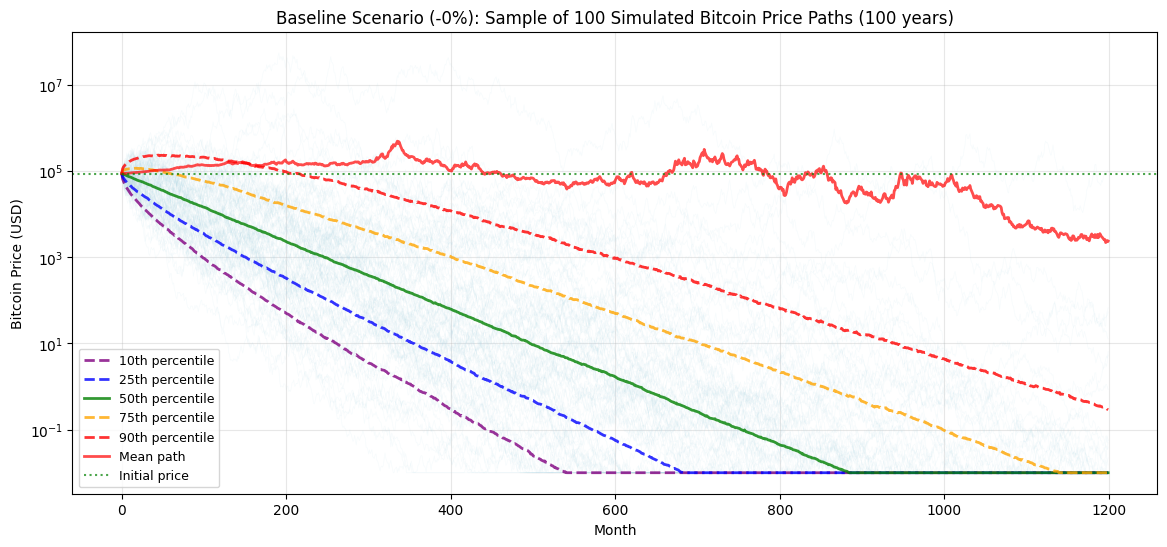

In [51]:
# ============================================================================
# LOAD BITCOIN PRICE PATHS FROM JSON (MULTIPLE SCENARIOS)
# ============================================================================

import json
import os

# Load price paths (try optimized split files first, then JSON formats)
price_paths_file = "output/btc_price_paths_scenarios_price_paths.npy"
metadata_file = "output/btc_price_paths_scenarios_metadata.npz"
json_file_scenarios = "output/btc_price_paths_scenarios.json"
json_file_old = "output/btc_price_paths.json"

use_npz = False
use_scenarios = False

# Try split files first (fastest - uncompressed large array, compressed metadata)
if os.path.exists(price_paths_file) and os.path.exists(metadata_file):
    print(f"Loading Bitcoin price paths from split files (optimized format)...")
    print(f"  Price paths: {price_paths_file}")
    print(f"  Metadata: {metadata_file}")
    use_npz = True
    use_scenarios = True
    
    # Load metadata
    metadata_npz = np.load(metadata_file)
    NUM_SIMULATIONS = int(metadata_npz['num_simulations'])
    SIMULATION_YEARS = int(metadata_npz['simulation_years'])
    TOTAL_MONTHS = int(metadata_npz['total_months'])
    CURRENT_BITCOIN_PRICE = float(metadata_npz['current_bitcoin_price'])
    NUM_SCENARIOS = int(metadata_npz['num_scenarios'])
    
    distribution_params = {
        'mean': float(metadata_npz['distribution_mean']),
        'std': float(metadata_npz['distribution_std']),
        'skew': float(metadata_npz['distribution_skew']),
        'kurtosis': float(metadata_npz['distribution_kurtosis']),
        'tail_weight': float(metadata_npz['distribution_tail_weight']),
        'asymmetry': float(metadata_npz['distribution_asymmetry'])
    }
    
    starting_price_pcts = metadata_npz['starting_price_pcts']
    starting_prices = metadata_npz['starting_prices']
    metadata_npz.close()
    
    # Load price paths (uncompressed, fast)
    print(f"  Loading price paths array ({os.path.getsize(price_paths_file) / (1024**3):.2f} GB)...")
    all_price_paths = np.load(price_paths_file)  # Already a numpy array
    
    # Convert to list of scenario dictionaries for compatibility
    scenarios = []
    for i in range(NUM_SCENARIOS):
        scenarios.append({
            'starting_price_pct': float(starting_price_pcts[i]),
            'starting_price': float(starting_prices[i]),
            'price_paths': all_price_paths[i].tolist()  # Convert to list for compatibility
        })
    
    print(f"✓ Successfully loaded {NUM_SCENARIOS} scenarios from split files (optimized format)!")
    print(f"  Each scenario: {NUM_SIMULATIONS:,} simulations")
    print(f"  Simulation period: {SIMULATION_YEARS} years ({TOTAL_MONTHS:,} months)")
    print(f"  Current Bitcoin price: ${CURRENT_BITCOIN_PRICE:,.2f}")
    print(f"\nScenarios:")
    for i, scenario in enumerate(scenarios):
        print(f"  {i+1:2d}. {scenario['starting_price_pct']*100:+6.0f}%: ${scenario['starting_price']:,.2f}")
    
elif os.path.exists(json_file_scenarios):
    json_file = json_file_scenarios
    use_scenarios = True
    print(f"Loading Bitcoin price paths from {json_file}...")
    with open(json_file, 'r') as f:
        price_data = json.load(f)
elif os.path.exists(json_file_old):
    json_file = json_file_old
    use_scenarios = False
    print(f"Loading Bitcoin price paths from {json_file}...")
    with open(json_file, 'r') as f:
        price_data = json.load(f)
else:
    raise FileNotFoundError(
        f"Error: None of the expected files found!\n"
        f"  Expected: {price_paths_file} and {metadata_file} (recommended), {json_file_scenarios}, or {json_file_old}\n"
        f"Please run btc_price_paths.py first to generate the price paths."
    )

if not use_npz:
    # Extract data from JSON format
    NUM_SIMULATIONS = price_data['num_simulations']
    SIMULATION_YEARS = price_data['simulation_years']
    TOTAL_MONTHS = price_data['total_months']
    distribution_params = price_data['distribution_params']

if use_scenarios and not use_npz:
    # New format with multiple scenarios (JSON)
    NUM_SCENARIOS = price_data.get('num_scenarios', 1)
    CURRENT_BITCOIN_PRICE = price_data.get('current_bitcoin_price', price_data.get('initial_price', 86817.19))
    scenarios = price_data['scenarios']
    
    print(f"✓ Successfully loaded {NUM_SCENARIOS} scenarios from JSON format!")
    print(f"  Each scenario: {NUM_SIMULATIONS:,} simulations")
    print(f"  Simulation period: {SIMULATION_YEARS} years ({TOTAL_MONTHS:,} months)")
    print(f"  Current Bitcoin price: ${CURRENT_BITCOIN_PRICE:,.2f}")
    print(f"\nScenarios:")
    for i, scenario in enumerate(scenarios):
        print(f"  {i+1:2d}. {scenario['starting_price_pct']*100:+6.0f}%: ${scenario['starting_price']:,.2f}")
elif not use_npz:
    # Old format (single scenario) - only reached when loading from JSON
    NUM_SCENARIOS = 1
    CURRENT_BITCOIN_PRICE = price_data.get('initial_price', price_data.get('current_bitcoin_price', 86817.19))
    simulated_prices = np.array(price_data['price_paths'])
    scenarios = [{
        'starting_price_pct': 0.0,
        'starting_price': CURRENT_BITCOIN_PRICE,
        'price_paths': price_data['price_paths']
    }]
    
    print(f"✓ Successfully loaded price paths (single scenario)!")
    print(f"  Number of simulations: {NUM_SIMULATIONS:,}")
    print(f"  Simulation period: {SIMULATION_YEARS} years ({TOTAL_MONTHS:,} months)")
    print(f"  Initial Bitcoin price: ${CURRENT_BITCOIN_PRICE:,.2f}")
# Note: If use_npz is True (loading from split files), scenarios are already set above

MONTHS_PER_YEAR = 12

print(f"\nDistribution parameters used:")
print(f"  Mean: {distribution_params['mean']:.4f}")
print(f"  Std Dev: {distribution_params['std']:.4f}")
print(f"  Skewness: {distribution_params['skew']:.4f}")
print(f"  Excess Kurtosis: {distribution_params['kurtosis']:.4f}")
print(f"  Tail Weight: {distribution_params['tail_weight']:.4f}")
print(f"  Asymmetry: {distribution_params['asymmetry']:.4f}")

# For backward compatibility, use baseline scenario (0%) for existing analysis
baseline_scenario_idx = NUM_SCENARIOS // 2 if NUM_SCENARIOS > 1 else 0
baseline_scenario = scenarios[baseline_scenario_idx]
simulated_prices = np.array(baseline_scenario['price_paths'])

# Verify dimensions
expected_shape = (NUM_SIMULATIONS, TOTAL_MONTHS)
if simulated_prices.shape != expected_shape:
    raise ValueError(
        f"Error: Price paths shape mismatch!\n"
        f"Expected: {expected_shape}, Got: {simulated_prices.shape}"
    )

# Display statistics for baseline scenario
print(f"\n{'='*70}")
print(f"BASELINE SCENARIO ({baseline_scenario['starting_price_pct']*100:+.0f}%) STATISTICS")
print(f"{'='*70}")
print(f"Price statistics across all simulations:")
print(f"  Initial price: ${baseline_scenario['starting_price']:,.2f}")
print(f"  Final price (mean): ${simulated_prices[:, -1].mean():,.2f}")
print(f"  Final price (median): ${np.median(simulated_prices[:, -1]):,.2f}")
print(f"  Final price (std): ${simulated_prices[:, -1].std():,.2f}")
print(f"  Final price (min): ${simulated_prices[:, -1].min():,.2f}")
print(f"  Final price (max): ${simulated_prices[:, -1].max():,.2f}")

# Plot sample of simulated paths with percentiles for baseline scenario
plt.figure(figsize=(14, 6))
sample_paths = min(100, NUM_SIMULATIONS)
for i in range(sample_paths):
    plt.plot(simulated_prices[i, :], alpha=0.1, linewidth=0.5, color='lightblue')

# Calculate percentiles across all simulations at each time point
percentiles = [10, 25, 50, 75, 90]
percentile_paths = {}
percentile_colors = {
    10: 'purple',
    25: 'blue',
    50: 'green',
    75: 'orange',
    90: 'red'
}
percentile_styles = {
    10: '--',
    25: '--',
    50: '-',  # Median gets solid line
    75: '--',
    90: '--'
}

for p in percentiles:
    percentile_paths[p] = np.percentile(simulated_prices, p, axis=0)
    plt.plot(percentile_paths[p], 
             color=percentile_colors[p], 
             linestyle=percentile_styles[p],
             linewidth=2, 
             label=f'{p}th percentile',
             alpha=0.8)

plt.plot(simulated_prices.mean(axis=0), 'r-', linewidth=2, label='Mean path', alpha=0.7)
plt.axhline(y=baseline_scenario['starting_price'], color='g', linestyle=':', linewidth=1.5, label='Initial price', alpha=0.7)
plt.title(f'Baseline Scenario ({baseline_scenario["starting_price_pct"]*100:+.0f}%): Sample of {sample_paths} Simulated Bitcoin Price Paths ({SIMULATION_YEARS} years)')
plt.xlabel('Month')
plt.ylabel('Bitcoin Price (USD)')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()


Calculating dividend sustainability for 10,000 simulations...

SATA Dividend Obligations:
  Total Annual: $24,500,000.00
  Total Monthly: $2,041,666.67

Dividend Suspension Threshold: 1.50x par value = $300,000,000
  Processed 1,000 simulations...
  Processed 2,000 simulations...
  Processed 3,000 simulations...
  Processed 4,000 simulations...
  Processed 5,000 simulations...
  Processed 6,000 simulations...
  Processed 7,000 simulations...
  Processed 8,000 simulations...
  Processed 9,000 simulations...
  Processed 10,000 simulations...

DIVIDEND SUSTAINABILITY RESULTS
Average months dividends paid: 86.2
Median months dividends paid: 52.0
Min months dividends paid: 2
Max months dividends paid: 1200

Simulations that paid full 1200 months: 2 (0.0%)
Simulations that paid < 12 months: 977 (9.8%)

Accumulated Unpaid Dividends (final):
  Mean: $2,215,936,648.30
  Median: $2,297,595,963.54
  Max: $2,486,484,157.99
  Simulations with unpaid dividends: 9,994 (99.9%)


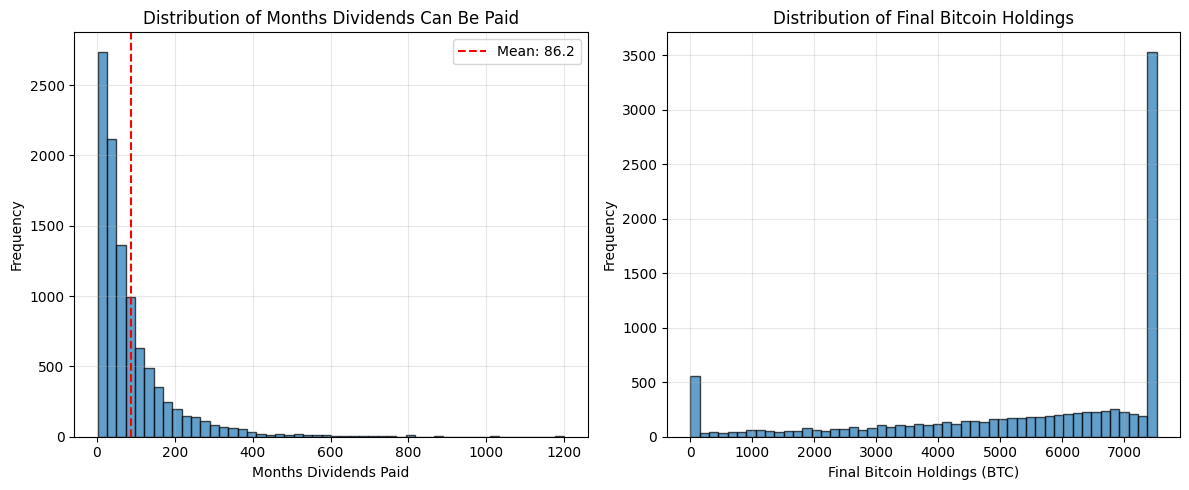

In [52]:
# Initialize arrays to store results
months_dividends_paid = np.zeros(NUM_SIMULATIONS)
final_bitcoin_holdings = np.zeros(NUM_SIMULATIONS)
final_cash_reserve = np.zeros(NUM_SIMULATIONS)
accumulated_unpaid_dividends_final = np.zeros(NUM_SIMULATIONS)

# Store dividend payment history for NPV calculation
# Each simulation will have: list of (month, amount, type) where type is 'regular' or 'accumulated'
dividend_payment_history = []

print(f"Calculating dividend sustainability for {NUM_SIMULATIONS:,} simulations...")
print(f"\nSATA Dividend Obligations:")
print(f"  Total Annual: ${SATA_ANNUAL_DIVIDEND_TOTAL:,.2f}")
print(f"  Total Monthly: ${SATA_MONTHLY_DIVIDEND_TOTAL:,.2f}")
print(f"\nDividend Suspension Threshold: {DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER:.2f}x par value = ${TOTAL_PAR_VALUE * DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER:,.0f}")

# Process each simulation
for sim in range(NUM_SIMULATIONS):
    cash_reserve = INITIAL_CASH_RESERVE
    bitcoin_holdings = INITIAL_BITCOIN_HOLDINGS
    months_paid = 0
    accumulated_unpaid_dividends = 0.0
    months_unpaid = 0
    
    # Track dividend payments for NPV calculation
    payment_history = []
    
    for month in range(TOTAL_MONTHS):
        # Get Bitcoin price for this month
        btc_price = simulated_prices[sim, month]
        
        # Calculate Bitcoin value
        bitcoin_value = bitcoin_holdings * btc_price
        threshold_value = TOTAL_PAR_VALUE * DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER
        
        if bitcoin_value >= threshold_value:
            # Bitcoin value is above threshold - can pay dividends
            total_payment_needed = 0
            
            # Step 1: Check if there are accumulated unpaid dividends to repay first
            if accumulated_unpaid_dividends > 0:
                total_payment_needed += accumulated_unpaid_dividends
            
            # Step 2: Add regular monthly dividend
            total_payment_needed += SATA_MONTHLY_DIVIDEND_TOTAL
            
            # Step 3: Attempt to pay from cash reserve first
            if cash_reserve >= total_payment_needed:
                # Can pay everything from cash
                if accumulated_unpaid_dividends > 0:
                    cash_reserve -= accumulated_unpaid_dividends
                    # Track accumulated dividend payment for NPV
                    payment_history.append((month, accumulated_unpaid_dividends, 'accumulated'))
                    accumulated_unpaid_dividends = 0
                    months_unpaid = 0  # Reset counter
                cash_reserve -= SATA_MONTHLY_DIVIDEND_TOTAL
                payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                months_paid += 1
            else:
                # Need to sell Bitcoin to cover payment
                shortfall = total_payment_needed - cash_reserve
                btc_needed = shortfall / btc_price if btc_price > 0 else float('inf')
                
                if bitcoin_holdings >= btc_needed:
                    # Can pay everything by selling Bitcoin
                    bitcoin_holdings -= btc_needed
                    if accumulated_unpaid_dividends > 0:
                        # Track accumulated dividend payment for NPV
                        payment_history.append((month, accumulated_unpaid_dividends, 'accumulated'))
                        accumulated_unpaid_dividends = 0
                        months_unpaid = 0  # Reset counter
                    cash_reserve = 0
                    payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                    months_paid += 1
                else:
                    # Cannot pay full amount - prioritize accumulated dividends
                    # Pay accumulated dividends first if possible
                    available_resources = cash_reserve + bitcoin_holdings * btc_price
                    
                    if accumulated_unpaid_dividends > 0:
                        # Try to pay accumulated dividends first
                        accumulated_payment = min(accumulated_unpaid_dividends, available_resources)
                        if accumulated_payment > 0:
                            # Pay what we can of accumulated dividends
                            accumulated_unpaid_dividends -= accumulated_payment
                            available_resources -= accumulated_payment
                            # Use cash first, then Bitcoin
                            if cash_reserve >= accumulated_payment:
                                cash_reserve -= accumulated_payment
                            else:
                                remaining = accumulated_payment - cash_reserve
                                cash_reserve = 0
                                bitcoin_holdings -= remaining / btc_price
                            payment_history.append((month, accumulated_payment, 'accumulated'))
                            if accumulated_unpaid_dividends == 0:
                                months_unpaid = 0  # Reset if fully paid
                    
                    # Then try to pay regular dividend if resources remain
                    if available_resources >= SATA_MONTHLY_DIVIDEND_TOTAL:
                        # Can pay regular dividend
                        if cash_reserve >= SATA_MONTHLY_DIVIDEND_TOTAL:
                            cash_reserve -= SATA_MONTHLY_DIVIDEND_TOTAL
                        else:
                            shortfall = SATA_MONTHLY_DIVIDEND_TOTAL - cash_reserve
                            cash_reserve = 0
                            bitcoin_holdings -= shortfall / btc_price
                        payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                        months_paid += 1
                    else:
                        # Cannot pay regular dividend - still suspended
                        # Accumulate regular dividend with compounded rate
                        compounded_rate = min(
                            COMPOUNDED_DIVIDEND_START_RATE + (months_unpaid * COMPOUNDED_DIVIDEND_INCREMENT),
                            COMPOUNDED_DIVIDEND_MAX_RATE
                        )
                        accumulated_unpaid_dividends += SATA_MONTHLY_DIVIDEND_TOTAL * (1 + compounded_rate/12)
                        months_unpaid += 1
        else:
            # Bitcoin value below threshold - suspend dividend
            # Accumulate unpaid dividend with compounded rate
            compounded_rate = min(
                COMPOUNDED_DIVIDEND_START_RATE + (months_unpaid * COMPOUNDED_DIVIDEND_INCREMENT),
                COMPOUNDED_DIVIDEND_MAX_RATE
            )
            accumulated_unpaid_dividends += SATA_MONTHLY_DIVIDEND_TOTAL * (1 + compounded_rate/12)
            months_unpaid += 1
    
    months_dividends_paid[sim] = months_paid
    final_bitcoin_holdings[sim] = bitcoin_holdings
    final_cash_reserve[sim] = cash_reserve
    accumulated_unpaid_dividends_final[sim] = accumulated_unpaid_dividends
    dividend_payment_history.append(payment_history)
    
    # Progress indicator
    if (sim + 1) % 1000 == 0:
        print(f"  Processed {sim + 1:,} simulations...")

print(f"\n" + "=" * 70)
print("DIVIDEND SUSTAINABILITY RESULTS")
print("=" * 70)
print(f"Average months dividends paid: {months_dividends_paid.mean():.1f}")
print(f"Median months dividends paid: {np.median(months_dividends_paid):.1f}")
print(f"Min months dividends paid: {months_dividends_paid.min():.0f}")
print(f"Max months dividends paid: {months_dividends_paid.max():.0f}")
print(f"\nSimulations that paid full {TOTAL_MONTHS} months: {(months_dividends_paid == TOTAL_MONTHS).sum():,} ({(months_dividends_paid == TOTAL_MONTHS).mean()*100:.1f}%)")
print(f"Simulations that paid < 12 months: {(months_dividends_paid < 12).sum():,} ({(months_dividends_paid < 12).mean()*100:.1f}%)")
print(f"\nAccumulated Unpaid Dividends (final):")
print(f"  Mean: ${accumulated_unpaid_dividends_final.mean():,.2f}")
print(f"  Median: ${np.median(accumulated_unpaid_dividends_final):,.2f}")
print(f"  Max: ${accumulated_unpaid_dividends_final.max():,.2f}")
print(f"  Simulations with unpaid dividends: {(accumulated_unpaid_dividends_final > 0).sum():,} ({(accumulated_unpaid_dividends_final > 0).mean()*100:.1f}%)")

# Plot distribution of months paid
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(months_dividends_paid, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(months_dividends_paid.mean(), color='r', linestyle='--', label=f'Mean: {months_dividends_paid.mean():.1f}')
plt.xlabel('Months Dividends Paid')
plt.ylabel('Frequency')
plt.title('Distribution of Months Dividends Can Be Paid')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(final_bitcoin_holdings, bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('Final Bitcoin Holdings (BTC)')
plt.ylabel('Frequency')
plt.title('Distribution of Final Bitcoin Holdings')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 3: NPV Calculation

For each simulation, calculate the Net Present Value of all dividend payments.


Calculating NPV for 10,000 simulations...
Discount rate (annual): 4.8%
Discount rate (monthly): 0.3903%
  Processed 1,000 simulations...
  Processed 2,000 simulations...
  Processed 3,000 simulations...
  Processed 4,000 simulations...
  Processed 5,000 simulations...
  Processed 6,000 simulations...
  Processed 7,000 simulations...
  Processed 8,000 simulations...
  Processed 9,000 simulations...
  Processed 10,000 simulations...

NPV CALCULATION RESULTS
Average NPV (total): $170,165,169.81
Average NPV per share: $85.08
Median NPV per share: $77.14
Std Dev NPV per share: $58.36

NPV Statistics (per share):
  5th percentile: $9.03
  25th percentile: $34.92
  75th percentile: $124.02
  95th percentile: $194.62


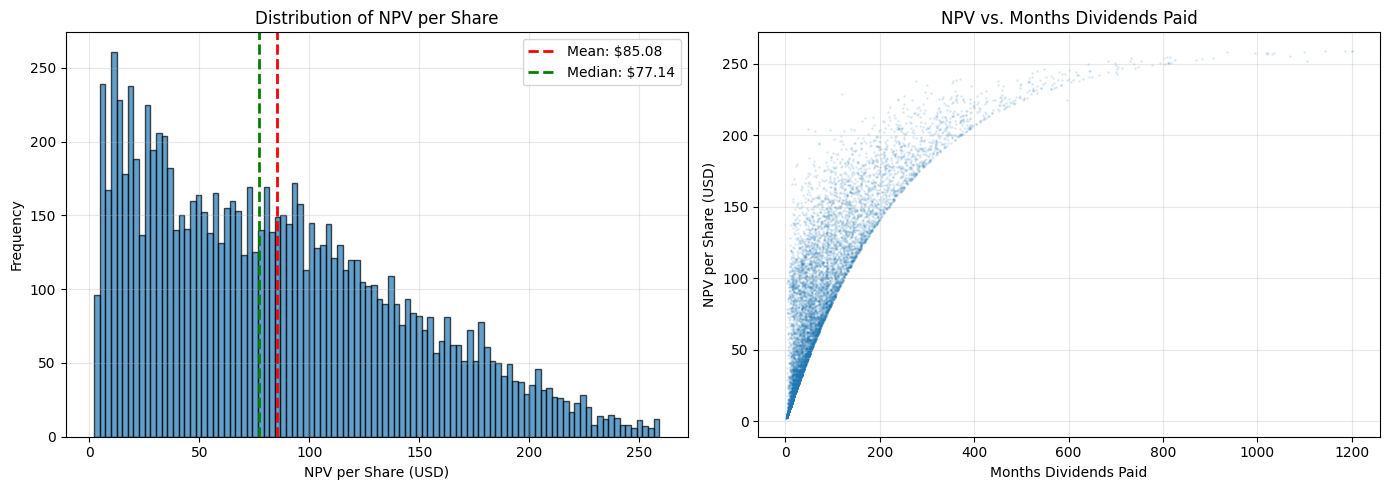

In [53]:
# Calculate NPV for each simulation
npvs = np.zeros(NUM_SIMULATIONS)
npvs_per_share = np.zeros(NUM_SIMULATIONS)

print(f"Calculating NPV for {NUM_SIMULATIONS:,} simulations...")
print(f"Discount rate (annual): {DISCOUNT_RATE_ANNUAL:.1%}")
print(f"Discount rate (monthly): {MONTHLY_DISCOUNT_RATE:.4%}")

for sim in range(NUM_SIMULATIONS):
    npv = 0
    payment_history = dividend_payment_history[sim]
    
    # Calculate NPV using payment history (includes both regular and accumulated dividends)
    for month, amount, payment_type in payment_history:
        # Discount factor for month (t+1 since first payment is at month 1)
        discount_factor = (1 + MONTHLY_DISCOUNT_RATE) ** (month + 1)
        
        # Add discounted dividend payment
        npv += amount / discount_factor
    
    npvs[sim] = npv
    npvs_per_share[sim] = npv / SATA_SHARES_OUTSTANDING
    
    # Progress indicator
    if (sim + 1) % 1000 == 0:
        print(f"  Processed {sim + 1:,} simulations...")

print(f"\n" + "=" * 70)
print("NPV CALCULATION RESULTS")
print("=" * 70)
print(f"Average NPV (total): ${npvs.mean():,.2f}")
print(f"Average NPV per share: ${npvs_per_share.mean():,.2f}")
print(f"Median NPV per share: ${np.median(npvs_per_share):,.2f}")
print(f"Std Dev NPV per share: ${npvs_per_share.std():,.2f}")
print(f"\nNPV Statistics (per share):")
print(f"  5th percentile: ${np.percentile(npvs_per_share, 5):,.2f}")
print(f"  25th percentile: ${np.percentile(npvs_per_share, 25):,.2f}")
print(f"  75th percentile: ${np.percentile(npvs_per_share, 75):,.2f}")
print(f"  95th percentile: ${np.percentile(npvs_per_share, 95):,.2f}")

# Plot distribution of NPVs
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(npvs_per_share, bins=100, edgecolor='k', alpha=0.7)
plt.axvline(npvs_per_share.mean(), color='r', linestyle='--', linewidth=2, 
            label=f'Mean: ${npvs_per_share.mean():,.2f}')
plt.axvline(np.median(npvs_per_share), color='g', linestyle='--', linewidth=2,
            label=f'Median: ${np.median(npvs_per_share):,.2f}')
plt.xlabel('NPV per Share (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of NPV per Share')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(months_dividends_paid, npvs_per_share, alpha=0.1, s=1)
plt.xlabel('Months Dividends Paid')
plt.ylabel('NPV per Share (USD)')
plt.title('NPV vs. Months Dividends Paid')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [54]:
# Final valuation (baseline scenario)
FINAL_VALUATION_PER_SHARE = npvs_per_share.mean()
FINAL_VALUATION_TOTAL = npvs.mean()

print("=" * 70)
print("FINAL SATA VALUATION RESULTS (BASELINE SCENARIO)")
print("=" * 70)
print(f"\nEstimated Fair Value per Share: ${FINAL_VALUATION_PER_SHARE:,.2f}")
print(f"Estimated Total Fair Value: ${FINAL_VALUATION_TOTAL:,.2f}")
print(f"\nPar Value: ${SATA_PAR_VALUE:,.2f}")
print(f"Valuation vs Par: {(FINAL_VALUATION_PER_SHARE / SATA_PAR_VALUE - 1)*100:+.2f}%")
print(f"\n" + "=" * 70)

# Summary statistics
print("\nSUMMARY STATISTICS")
print("=" * 70)
print(f"\nSimulation Parameters:")
print(f"  Number of simulations: {NUM_SIMULATIONS:,}")
print(f"  Projection period: {SIMULATION_YEARS} years ({TOTAL_MONTHS:,} months)")
print(f"  Mean CAGR: {MEAN_CAGR:.1%}")

print(f"\nDividend Sustainability:")
print(f"  Average months paid: {months_dividends_paid.mean():.1f} months ({months_dividends_paid.mean()/12:.1f} years)")
print(f"  Median months paid: {np.median(months_dividends_paid):.1f} months ({np.median(months_dividends_paid)/12:.1f} years)")
print(f"  Probability of paying full period: {(months_dividends_paid == TOTAL_MONTHS).mean()*100:.2f}%")

print(f"\nValuation:")
print(f"  Mean NPV per share: ${npvs_per_share.mean():,.2f}")
print(f"  Median NPV per share: ${np.median(npvs_per_share):,.2f}")
print(f"  Standard deviation: ${npvs_per_share.std():,.2f}")
print(f"  Coefficient of variation: {npvs_per_share.std()/npvs_per_share.mean():.2%}")

print("\n" + "=" * 70)


FINAL SATA VALUATION RESULTS (BASELINE SCENARIO)

Estimated Fair Value per Share: $85.08
Estimated Total Fair Value: $170,165,169.81

Par Value: $100.00
Valuation vs Par: -14.92%


SUMMARY STATISTICS

Simulation Parameters:
  Number of simulations: 10,000
  Projection period: 100 years (1,200 months)
  Mean CAGR: 0.0%

Dividend Sustainability:
  Average months paid: 86.2 months (7.2 years)
  Median months paid: 52.0 months (4.3 years)
  Probability of paying full period: 0.02%

Valuation:
  Mean NPV per share: $85.08
  Median NPV per share: $77.14
  Standard deviation: $58.36
  Coefficient of variation: 68.60%



## Step 4: Multi-Scenario NPV Analysis

Calculate NPV for each Bitcoin price scenario (-10% to +10% starting prices) and analyze how starting price affects SATA valuation.


In [55]:
# ============================================================================
# CALCULATE NPV FOR EACH SCENARIO
# ============================================================================

if NUM_SCENARIOS > 1:
    print(f"\n{'='*70}")
    print(f"MULTI-SCENARIO NPV ANALYSIS")
    print(f"{'='*70}")
    print(f"Calculating NPV for {NUM_SCENARIOS} scenarios...")
    print(f"Each scenario uses {NUM_SIMULATIONS:,} simulations")
    print(f"Discount rate (annual): {DISCOUNT_RATE_ANNUAL:.1%}")
    print(f"Discount rate (monthly): {MONTHLY_DISCOUNT_RATE:.4%}")
    
    scenario_results = []
    
    for scenario_idx, scenario in enumerate(scenarios):
        starting_price_pct = scenario['starting_price_pct']
        starting_price = scenario['starting_price']
        price_paths = np.array(scenario['price_paths'])
        
        print(f"\nScenario {scenario_idx + 1}/{NUM_SCENARIOS}: Starting price {starting_price_pct*100:+.0f}% (${starting_price:,.2f})")
        
        # Initialize arrays to store results for this scenario
        months_dividends_paid_scenario = np.zeros(NUM_SIMULATIONS)
        scenario_payment_history = []
        
        # Calculate dividend sustainability for this scenario
        for sim in range(NUM_SIMULATIONS):
            cash_reserve = INITIAL_CASH_RESERVE
            bitcoin_holdings = INITIAL_BITCOIN_HOLDINGS
            months_paid = 0
            accumulated_unpaid_dividends = 0.0
            months_unpaid = 0
            
            # Track dividend payments for NPV calculation
            payment_history = []
            
            for month in range(TOTAL_MONTHS):
                # Get Bitcoin price for this month
                btc_price = price_paths[sim, month]
                
                # Calculate Bitcoin value
                bitcoin_value = bitcoin_holdings * btc_price
                threshold_value = TOTAL_PAR_VALUE * DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER
                
                if bitcoin_value >= threshold_value:
                    # Bitcoin value is above threshold - can pay dividends
                    total_payment_needed = 0
                    
                    # Step 1: Check if there are accumulated unpaid dividends to repay first
                    if accumulated_unpaid_dividends > 0:
                        total_payment_needed += accumulated_unpaid_dividends
                    
                    # Step 2: Add regular monthly dividend
                    total_payment_needed += SATA_MONTHLY_DIVIDEND_TOTAL
                    
                    # Step 3: Attempt to pay from cash reserve first
                    if cash_reserve >= total_payment_needed:
                        # Can pay everything from cash
                        if accumulated_unpaid_dividends > 0:
                            cash_reserve -= accumulated_unpaid_dividends
                            payment_history.append((month, accumulated_unpaid_dividends, 'accumulated'))
                            accumulated_unpaid_dividends = 0
                            months_unpaid = 0
                        cash_reserve -= SATA_MONTHLY_DIVIDEND_TOTAL
                        payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                        months_paid += 1
                    else:
                        # Need to sell Bitcoin to cover payment
                        shortfall = total_payment_needed - cash_reserve
                        btc_needed = shortfall / btc_price if btc_price > 0 else float('inf')
                        
                        if bitcoin_holdings >= btc_needed:
                            # Can pay everything by selling Bitcoin
                            bitcoin_holdings -= btc_needed
                            if accumulated_unpaid_dividends > 0:
                                payment_history.append((month, accumulated_unpaid_dividends, 'accumulated'))
                                accumulated_unpaid_dividends = 0
                                months_unpaid = 0
                            cash_reserve = 0
                            payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                            months_paid += 1
                        else:
                            # Cannot pay full amount - prioritize accumulated dividends
                            available_resources = cash_reserve + bitcoin_holdings * btc_price
                            
                            if accumulated_unpaid_dividends > 0:
                                accumulated_payment = min(accumulated_unpaid_dividends, available_resources)
                                if accumulated_payment > 0:
                                    accumulated_unpaid_dividends -= accumulated_payment
                                    available_resources -= accumulated_payment
                                    if cash_reserve >= accumulated_payment:
                                        cash_reserve -= accumulated_payment
                                    else:
                                        remaining = accumulated_payment - cash_reserve
                                        cash_reserve = 0
                                        bitcoin_holdings -= remaining / btc_price
                                    payment_history.append((month, accumulated_payment, 'accumulated'))
                                    if accumulated_unpaid_dividends == 0:
                                        months_unpaid = 0
                            
                            # Then try to pay regular dividend if resources remain
                            if available_resources >= SATA_MONTHLY_DIVIDEND_TOTAL:
                                if cash_reserve >= SATA_MONTHLY_DIVIDEND_TOTAL:
                                    cash_reserve -= SATA_MONTHLY_DIVIDEND_TOTAL
                                else:
                                    shortfall = SATA_MONTHLY_DIVIDEND_TOTAL - cash_reserve
                                    cash_reserve = 0
                                    bitcoin_holdings -= shortfall / btc_price
                                payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                                months_paid += 1
                            else:
                                # Cannot pay regular dividend - still suspended
                                compounded_rate = min(
                                    COMPOUNDED_DIVIDEND_START_RATE + (months_unpaid * COMPOUNDED_DIVIDEND_INCREMENT),
                                    COMPOUNDED_DIVIDEND_MAX_RATE
                                )
                                accumulated_unpaid_dividends += SATA_MONTHLY_DIVIDEND_TOTAL * (1 + compounded_rate/12)
                                months_unpaid += 1
                else:
                    # Bitcoin value below threshold - suspend dividend
                    compounded_rate = min(
                        COMPOUNDED_DIVIDEND_START_RATE + (months_unpaid * COMPOUNDED_DIVIDEND_INCREMENT),
                        COMPOUNDED_DIVIDEND_MAX_RATE
                    )
                    accumulated_unpaid_dividends += SATA_MONTHLY_DIVIDEND_TOTAL * (1 + compounded_rate/12)
                    months_unpaid += 1
            
            months_dividends_paid_scenario[sim] = months_paid
            scenario_payment_history.append(payment_history)
        
        # Calculate NPV for this scenario
        npvs_scenario = np.zeros(NUM_SIMULATIONS)
        npvs_per_share_scenario = np.zeros(NUM_SIMULATIONS)
        
        for sim in range(NUM_SIMULATIONS):
            npv = 0
            payment_history = scenario_payment_history[sim]
            
            # Calculate NPV using payment history (includes both regular and accumulated dividends)
            for month, amount, payment_type in payment_history:
                discount_factor = (1 + MONTHLY_DISCOUNT_RATE) ** (month + 1)
                npv += amount / discount_factor
            
            npvs_scenario[sim] = npv
            npvs_per_share_scenario[sim] = npv / SATA_SHARES_OUTSTANDING
        
        # Store results
        mean_npv_per_share = npvs_per_share_scenario.mean()
        median_npv_per_share = np.median(npvs_per_share_scenario)
        mean_months_paid = months_dividends_paid_scenario.mean()
        
        scenario_results.append({
            'starting_price_pct': starting_price_pct,
            'starting_price': starting_price,
            'mean_npv_per_share': mean_npv_per_share,
            'median_npv_per_share': median_npv_per_share,
            'mean_months_paid': mean_months_paid,
            'std_npv_per_share': npvs_per_share_scenario.std(),
            'min_npv_per_share': npvs_per_share_scenario.min(),
            'max_npv_per_share': npvs_per_share_scenario.max()
        })
        
        print(f"  ✓ Mean NPV per share: ${mean_npv_per_share:,.2f}")
        print(f"  ✓ Mean months paid: {mean_months_paid:.1f}")
        
        # Progress indicator
        if (scenario_idx + 1) % 5 == 0:
            print(f"\n  Progress: {scenario_idx + 1}/{NUM_SCENARIOS} scenarios completed...")
    
    # Create results DataFrame
    results_df = pd.DataFrame(scenario_results)
    results_df = results_df.sort_values('starting_price_pct')
    
    print(f"\n{'='*70}")
    print(f"SCENARIO ANALYSIS COMPLETE")
    print(f"{'='*70}")
    print(f"\nResults Summary:")
    print(results_df[['starting_price_pct', 'starting_price', 'mean_npv_per_share', 'mean_months_paid']].to_string(index=False))
    
else:
    print(f"\nNote: Only single scenario available. Multi-scenario analysis skipped.")
    print(f"Run btc_price_paths.py to generate multiple scenarios.")



MULTI-SCENARIO NPV ANALYSIS
Calculating NPV for 21 scenarios...
Each scenario uses 10,000 simulations
Discount rate (annual): 4.8%
Discount rate (monthly): 0.3903%

Scenario 1/21: Starting price -10% ($78,159.85)
  ✓ Mean NPV per share: $82.15
  ✓ Mean months paid: 81.1

Scenario 2/21: Starting price -9% ($79,028.30)
  ✓ Mean NPV per share: $82.49
  ✓ Mean months paid: 81.6

Scenario 3/21: Starting price -8% ($79,896.74)
  ✓ Mean NPV per share: $82.80
  ✓ Mean months paid: 82.2

Scenario 4/21: Starting price -7% ($80,765.18)
  ✓ Mean NPV per share: $83.10
  ✓ Mean months paid: 82.7

Scenario 5/21: Starting price -6% ($81,633.62)
  ✓ Mean NPV per share: $83.35
  ✓ Mean months paid: 83.2

  Progress: 5/21 scenarios completed...

Scenario 6/21: Starting price -5% ($82,502.07)
  ✓ Mean NPV per share: $83.67
  ✓ Mean months paid: 83.7

Scenario 7/21: Starting price -4% ($83,370.51)
  ✓ Mean NPV per share: $83.97
  ✓ Mean months paid: 84.2

Scenario 8/21: Starting price -3% ($84,238.95)
  ✓


TREND LINE ANALYSIS
Slope (Delta): $0.2801 per 1% change in Bitcoin starting price
  Interpretation: For every 1% increase in Bitcoin starting price,
                   NPV increases by approximately $0.28 per share
Intercept: $85.06
R-squared: 0.9986


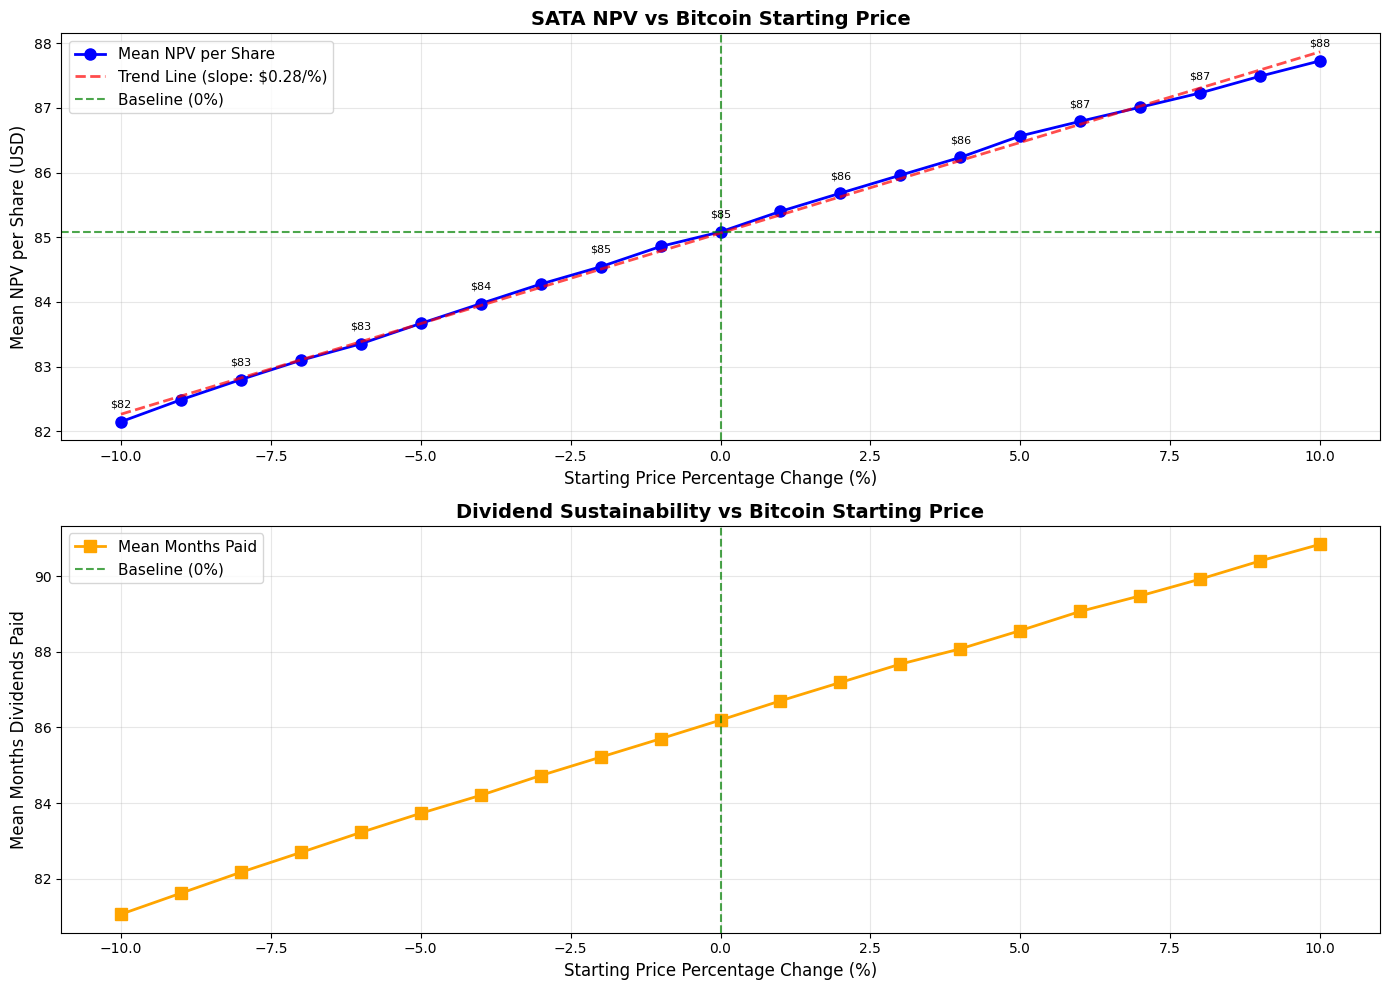


DETAILED SCENARIO RESULTS

 starting_price_pct  starting_price  mean_npv_per_share  median_npv_per_share  mean_months_paid  std_npv_per_share  min_npv_per_share  max_npv_per_share
      -1.000000e-01    78159.851562           82.147236             73.398100           81.0555          58.363776           2.029774         259.085351
      -9.000000e-02    79028.296875           82.486572             73.732873           81.6128          58.377993           2.029774         259.085351
      -8.000000e-02    79896.742188           82.799480             74.159354           82.1669          58.384589           2.029774         259.085351
      -7.000000e-02    80765.179688           83.096600             74.385956           82.6909          58.379966           2.029774         259.085351
      -6.000000e-02    81633.625000           83.352194             74.520888           83.2208          58.367911           2.029774         259.083944
      -5.000000e-02    82502.070312           83.66661

In [56]:
# ============================================================================
# VISUALIZE NPV VS STARTING PRICE PERCENTAGE
# ============================================================================

if NUM_SCENARIOS > 1:
    # Create visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Mean NPV per share vs starting price percentage
    ax1 = axes[0]
    x_data = results_df['starting_price_pct'] * 100  # Convert to percentage
    y_data = results_df['mean_npv_per_share']
    
    ax1.plot(x_data, y_data, 
             marker='o', linewidth=2, markersize=8, color='blue', label='Mean NPV per Share')
    
    # Fit linear trend line
    slope, intercept = np.polyfit(x_data, y_data, 1)
    trend_line = slope * x_data + intercept
    
    # Plot trend line
    ax1.plot(x_data, trend_line, 
             linestyle='--', linewidth=2, color='red', alpha=0.7, 
             label=f'Trend Line (slope: ${slope:.2f}/%)')
    
    ax1.axvline(x=0, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (0%)')
    baseline_mask_plot = np.isclose(results_df['starting_price_pct'], 0, atol=1e-6)
    baseline_npv_plot = results_df[baseline_mask_plot]['mean_npv_per_share'].values[0] if baseline_mask_plot.sum() > 0 else results_df['mean_npv_per_share'].iloc[NUM_SCENARIOS//2]
    ax1.axhline(y=baseline_npv_plot, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    ax1.set_xlabel('Starting Price Percentage Change (%)', fontsize=12)
    ax1.set_ylabel('Mean NPV per Share (USD)', fontsize=12)
    ax1.set_title('SATA NPV vs Bitcoin Starting Price', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    
    # Print trend line statistics
    print(f"\n{'='*70}")
    print(f"TREND LINE ANALYSIS")
    print(f"{'='*70}")
    print(f"Slope (Delta): ${slope:.4f} per 1% change in Bitcoin starting price")
    print(f"  Interpretation: For every 1% increase in Bitcoin starting price,")
    print(f"                   NPV increases by approximately ${slope:.2f} per share")
    print(f"Intercept: ${intercept:.2f}")
    print(f"R-squared: {np.corrcoef(x_data, y_data)[0,1]**2:.4f}")
    
    # Add value labels on points
    for idx, row in results_df.iterrows():
        if idx % 2 == 0:  # Label every other point to avoid clutter
            ax1.annotate(f'${row["mean_npv_per_share"]:,.0f}', 
                        (row['starting_price_pct'] * 100, row['mean_npv_per_share']),
                        textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
    
    # Plot 2: Mean months paid vs starting price percentage
    ax2 = axes[1]
    ax2.plot(results_df['starting_price_pct'] * 100, results_df['mean_months_paid'], 
             marker='s', linewidth=2, markersize=8, color='orange', label='Mean Months Paid')
    ax2.axvline(x=0, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (0%)')
    ax2.set_xlabel('Starting Price Percentage Change (%)', fontsize=12)
    ax2.set_ylabel('Mean Months Dividends Paid', fontsize=12)
    ax2.set_title('Dividend Sustainability vs Bitcoin Starting Price', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results table
    print(f"\n{'='*70}")
    print(f"DETAILED SCENARIO RESULTS")
    print(f"{'='*70}")
    print(f"\n{results_df.to_string(index=False)}")
    
    # Summary statistics
    print(f"\n{'='*70}")
    print(f"SCENARIO ANALYSIS SUMMARY")
    print(f"{'='*70}")
    print(f"\nNPV Range:")
    print(f"  Minimum NPV: ${results_df['mean_npv_per_share'].min():,.2f} (at {results_df.loc[results_df['mean_npv_per_share'].idxmin(), 'starting_price_pct']*100:+.0f}%)")
    print(f"  Maximum NPV: ${results_df['mean_npv_per_share'].max():,.2f} (at {results_df.loc[results_df['mean_npv_per_share'].idxmax(), 'starting_price_pct']*100:+.0f}%)")
    print(f"  NPV Range: ${results_df['mean_npv_per_share'].max() - results_df['mean_npv_per_share'].min():,.2f}")
    
    # Find baseline NPV (0% scenario) using tolerance-based comparison
    baseline_mask = np.isclose(results_df['starting_price_pct'], 0, atol=1e-6)
    baseline_npv = results_df[baseline_mask]['mean_npv_per_share'].values[0] if baseline_mask.sum() > 0 else results_df['mean_npv_per_share'].iloc[NUM_SCENARIOS//2]
    print(f"\nBaseline NPV (0%): ${baseline_npv:,.2f}")
    print(f"\nNPV Change from Baseline:")
    
    # Find -10% and +10% scenarios using tolerance-based comparison
    neg_10_mask = np.isclose(results_df['starting_price_pct'], -0.10, atol=1e-6)
    pos_10_mask = np.isclose(results_df['starting_price_pct'], 0.10, atol=1e-6)
    
    if neg_10_mask.sum() > 0:
        neg_10_npv = results_df[neg_10_mask]['mean_npv_per_share'].values[0]
        neg_10_change = ((neg_10_npv - baseline_npv) / baseline_npv * 100)
        print(f"  -10% scenario: {neg_10_change:+.2f}%")
    else:
        print(f"  -10% scenario: Not available")
    
    if pos_10_mask.sum() > 0:
        pos_10_npv = results_df[pos_10_mask]['mean_npv_per_share'].values[0]
        pos_10_change = ((pos_10_npv - baseline_npv) / baseline_npv * 100)
        print(f"  +10% scenario: {pos_10_change:+.2f}%")
    else:
        print(f"  +10% scenario: Not available")
    
    print(f"\n{'='*70}")
else:
    print(f"\nNote: Multi-scenario visualization skipped (only single scenario available).")


## Step 5: Sensitivity Analysis - Dividend Suspension Threshold

Analyze how different suspension threshold multipliers affect NPV and dividend sustainability.



SENSITIVITY ANALYSIS: DIVIDEND SUSPENSION THRESHOLD

Testing 9 threshold multipliers:
  Range: 0.00x to 2.00x par value
  Using baseline scenario with 10,000 simulations
  Discount rate (annual): 4.8%

  [1/9] Testing threshold: 0.00x par value ($0)
    ✓ Mean NPV: $103.52 | Mean months: 143.5 | Unpaid: $2,191,857,647

  [2/9] Testing threshold: 0.25x par value ($50,000,000)
    ✓ Mean NPV: $102.21 | Mean months: 127.1 | Unpaid: $2,190,253,954

  [3/9] Testing threshold: 0.50x par value ($100,000,000)
    ✓ Mean NPV: $99.29 | Mean months: 115.7 | Unpaid: $2,191,758,697

  [4/9] Testing threshold: 0.75x par value ($150,000,000)
    ✓ Mean NPV: $95.71 | Mean months: 106.7 | Unpaid: $2,196,278,904

  [5/9] Testing threshold: 1.00x par value ($200,000,000)
    ✓ Mean NPV: $91.96 | Mean months: 99.0 | Unpaid: $2,202,766,196

  [6/9] Testing threshold: 1.25x par value ($250,000,000)
    ✓ Mean NPV: $88.48 | Mean months: 92.2 | Unpaid: $2,209,142,842

  [7/9] Testing threshold: 1.50x par val

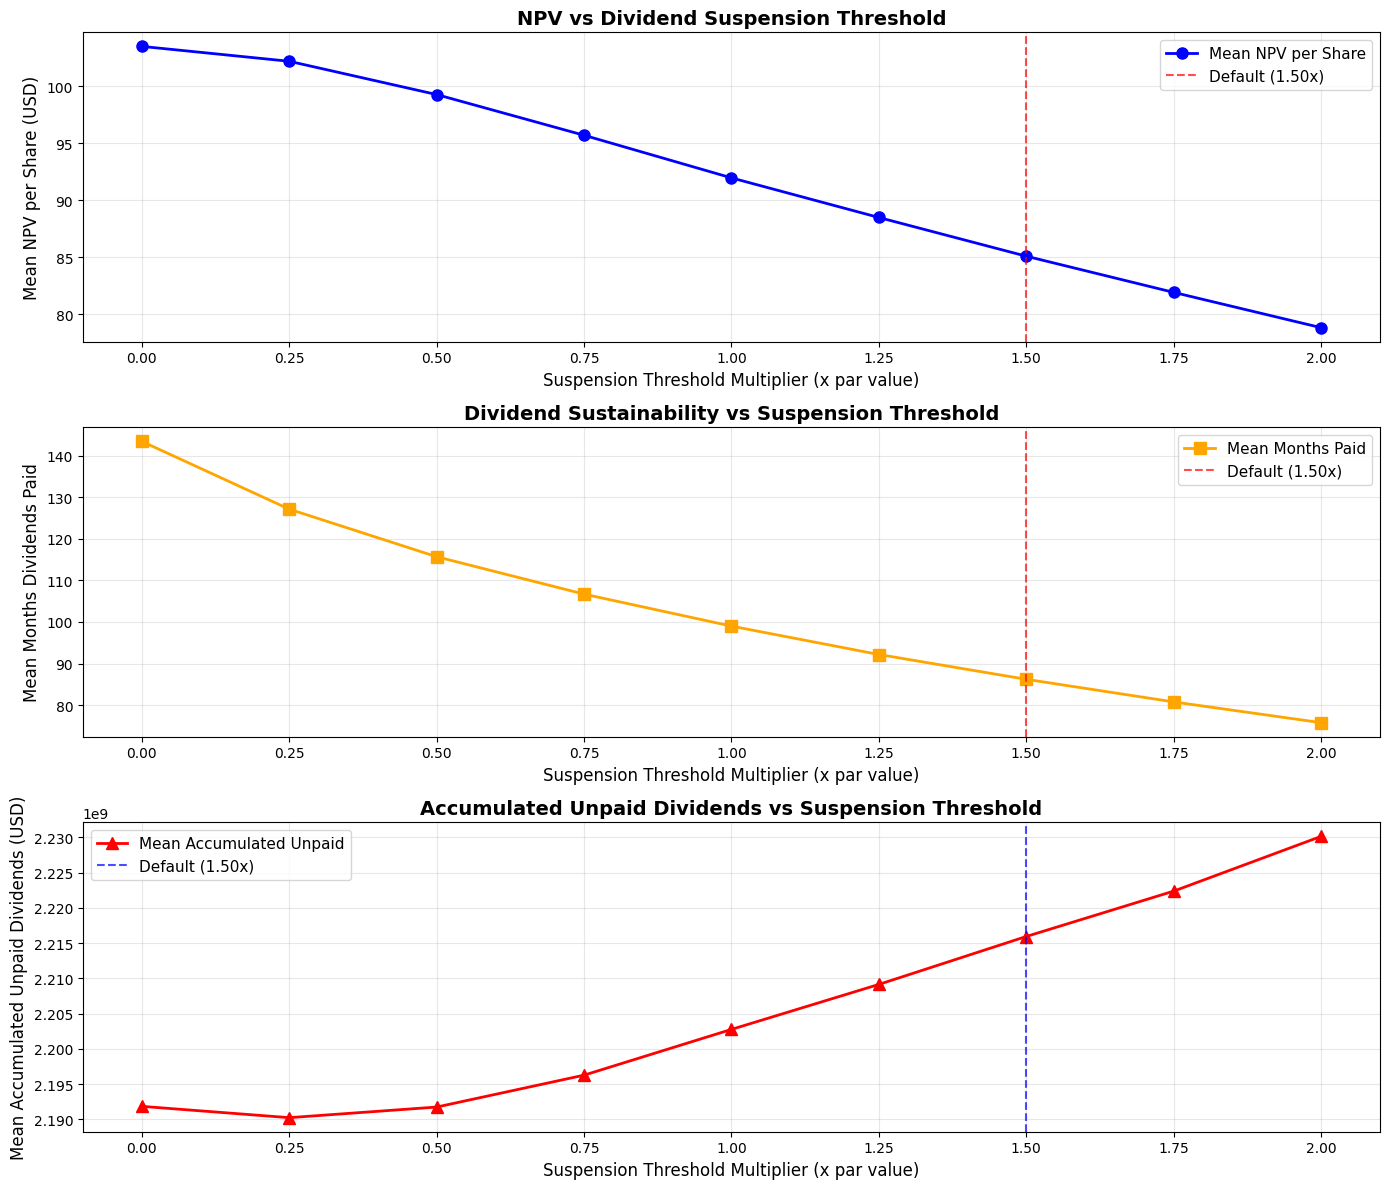


SENSITIVITY ANALYSIS SUMMARY

NPV Range:
  Minimum NPV: $78.80 (at 2.00x)
  Maximum NPV: $103.52 (at 0.00x)
  NPV Range: $24.71

Default Threshold (1.50x):
  Mean NPV: $85.08
  Mean months paid: 86.2
  Mean accumulated unpaid: $2,215,936,648.30
  Probability of full payment: 0.02%



In [57]:
# ============================================================================
# SENSITIVITY ANALYSIS: DIVIDEND SUSPENSION THRESHOLD MULTIPLIER
# ============================================================================

print(f"\n{'='*70}")
print(f"SENSITIVITY ANALYSIS: DIVIDEND SUSPENSION THRESHOLD")
print(f"{'='*70}")

# Test multipliers from 0.5x to 2.0x in 0.25x increments
threshold_multipliers = np.arange(0, 2.25, 0.25)
sensitivity_results = []

print(f"\nTesting {len(threshold_multipliers)} threshold multipliers:")
print(f"  Range: {threshold_multipliers[0]:.2f}x to {threshold_multipliers[-1]:.2f}x par value")
print(f"  Using baseline scenario with {NUM_SIMULATIONS:,} simulations")
print(f"  Discount rate (annual): {DISCOUNT_RATE_ANNUAL:.1%}")

for mult_idx, threshold_mult in enumerate(threshold_multipliers):
    print(f"\n  [{mult_idx + 1}/{len(threshold_multipliers)}] Testing threshold: {threshold_mult:.2f}x par value (${TOTAL_PAR_VALUE * threshold_mult:,.0f})")
    
    # Initialize arrays for this threshold
    months_paid_threshold = np.zeros(NUM_SIMULATIONS)
    npvs_threshold = np.zeros(NUM_SIMULATIONS)
    npvs_per_share_threshold = np.zeros(NUM_SIMULATIONS)
    accumulated_unpaid_final = np.zeros(NUM_SIMULATIONS)
    
    # Run simulation with this threshold
    for sim in range(NUM_SIMULATIONS):
        cash_reserve = INITIAL_CASH_RESERVE
        bitcoin_holdings = INITIAL_BITCOIN_HOLDINGS
        months_paid = 0
        accumulated_unpaid_dividends = 0.0
        months_unpaid = 0
        payment_history = []
        
        for month in range(TOTAL_MONTHS):
            btc_price = simulated_prices[sim, month]
            bitcoin_value = bitcoin_holdings * btc_price
            threshold_value = TOTAL_PAR_VALUE * threshold_mult
            
            if bitcoin_value >= threshold_value:
                # Can pay dividends
                total_payment_needed = 0
                if accumulated_unpaid_dividends > 0:
                    total_payment_needed += accumulated_unpaid_dividends
                total_payment_needed += SATA_MONTHLY_DIVIDEND_TOTAL
                
                if cash_reserve >= total_payment_needed:
                    if accumulated_unpaid_dividends > 0:
                        cash_reserve -= accumulated_unpaid_dividends
                        payment_history.append((month, accumulated_unpaid_dividends, 'accumulated'))
                        accumulated_unpaid_dividends = 0
                        months_unpaid = 0
                    cash_reserve -= SATA_MONTHLY_DIVIDEND_TOTAL
                    payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                    months_paid += 1
                else:
                    shortfall = total_payment_needed - cash_reserve
                    btc_needed = shortfall / btc_price if btc_price > 0 else float('inf')
                    
                    if bitcoin_holdings >= btc_needed:
                        bitcoin_holdings -= btc_needed
                        if accumulated_unpaid_dividends > 0:
                            payment_history.append((month, accumulated_unpaid_dividends, 'accumulated'))
                            accumulated_unpaid_dividends = 0
                            months_unpaid = 0
                        cash_reserve = 0
                        payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                        months_paid += 1
                    else:
                        available_resources = cash_reserve + bitcoin_holdings * btc_price
                        
                        if accumulated_unpaid_dividends > 0:
                            accumulated_payment = min(accumulated_unpaid_dividends, available_resources)
                            if accumulated_payment > 0:
                                accumulated_unpaid_dividends -= accumulated_payment
                                available_resources -= accumulated_payment
                                if cash_reserve >= accumulated_payment:
                                    cash_reserve -= accumulated_payment
                                else:
                                    remaining = accumulated_payment - cash_reserve
                                    cash_reserve = 0
                                    bitcoin_holdings -= remaining / btc_price
                                payment_history.append((month, accumulated_payment, 'accumulated'))
                                if accumulated_unpaid_dividends == 0:
                                    months_unpaid = 0
                        
                        if available_resources >= SATA_MONTHLY_DIVIDEND_TOTAL:
                            if cash_reserve >= SATA_MONTHLY_DIVIDEND_TOTAL:
                                cash_reserve -= SATA_MONTHLY_DIVIDEND_TOTAL
                            else:
                                shortfall = SATA_MONTHLY_DIVIDEND_TOTAL - cash_reserve
                                cash_reserve = 0
                                bitcoin_holdings -= shortfall / btc_price
                            payment_history.append((month, SATA_MONTHLY_DIVIDEND_TOTAL, 'regular'))
                            months_paid += 1
                        else:
                            compounded_rate = min(
                                COMPOUNDED_DIVIDEND_START_RATE + (months_unpaid * COMPOUNDED_DIVIDEND_INCREMENT),
                                COMPOUNDED_DIVIDEND_MAX_RATE
                            )
                            accumulated_unpaid_dividends += SATA_MONTHLY_DIVIDEND_TOTAL * (1 + compounded_rate/12)
                            months_unpaid += 1
            else:
                # Suspend dividend
                compounded_rate = min(
                    COMPOUNDED_DIVIDEND_START_RATE + (months_unpaid * COMPOUNDED_DIVIDEND_INCREMENT),
                    COMPOUNDED_DIVIDEND_MAX_RATE
                )
                accumulated_unpaid_dividends += SATA_MONTHLY_DIVIDEND_TOTAL * (1 + compounded_rate/12)
                months_unpaid += 1
        
        # Calculate NPV for this simulation
        npv = 0
        for month, amount, payment_type in payment_history:
            discount_factor = (1 + MONTHLY_DISCOUNT_RATE) ** (month + 1)
            npv += amount / discount_factor
        
        months_paid_threshold[sim] = months_paid
        npvs_threshold[sim] = npv
        npvs_per_share_threshold[sim] = npv / SATA_SHARES_OUTSTANDING
        accumulated_unpaid_final[sim] = accumulated_unpaid_dividends
    
    # Store results
    sensitivity_results.append({
        'threshold_multiplier': threshold_mult,
        'threshold_value': TOTAL_PAR_VALUE * threshold_mult,
        'mean_npv_per_share': npvs_per_share_threshold.mean(),
        'median_npv_per_share': np.median(npvs_per_share_threshold),
        'mean_months_paid': months_paid_threshold.mean(),
        'mean_accumulated_unpaid': accumulated_unpaid_final.mean(),
        'prob_full_payment': (months_paid_threshold == TOTAL_MONTHS).mean(),
        'std_npv_per_share': npvs_per_share_threshold.std()
    })
    
    print(f"    ✓ Mean NPV: ${npvs_per_share_threshold.mean():,.2f} | Mean months: {months_paid_threshold.mean():.1f} | Unpaid: ${accumulated_unpaid_final.mean():,.0f}")

# Create results DataFrame
sensitivity_df = pd.DataFrame(sensitivity_results)

print(f"\n{'='*70}")
print(f"SENSITIVITY ANALYSIS COMPLETE")
print(f"{'='*70}")

# Display results table
print(f"\n{sensitivity_df[['threshold_multiplier', 'threshold_value', 'mean_npv_per_share', 'mean_months_paid', 'mean_accumulated_unpaid', 'prob_full_payment']].to_string(index=False)}")

# Create visualizations
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: NPV vs Threshold Multiplier
ax1 = axes[0]
ax1.plot(sensitivity_df['threshold_multiplier'], sensitivity_df['mean_npv_per_share'], 
         marker='o', linewidth=2, markersize=8, color='blue', label='Mean NPV per Share')
ax1.axvline(x=DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER, color='red', linestyle='--', 
            linewidth=1.5, alpha=0.7, label=f'Default ({DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER:.2f}x)')
ax1.set_xlabel('Suspension Threshold Multiplier (x par value)', fontsize=12)
ax1.set_ylabel('Mean NPV per Share (USD)', fontsize=12)
ax1.set_title('NPV vs Dividend Suspension Threshold', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Plot 2: Months Paid vs Threshold Multiplier
ax2 = axes[1]
ax2.plot(sensitivity_df['threshold_multiplier'], sensitivity_df['mean_months_paid'], 
         marker='s', linewidth=2, markersize=8, color='orange', label='Mean Months Paid')
ax2.axvline(x=DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER, color='red', linestyle='--', 
            linewidth=1.5, alpha=0.7, label=f'Default ({DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER:.2f}x)')
ax2.set_xlabel('Suspension Threshold Multiplier (x par value)', fontsize=12)
ax2.set_ylabel('Mean Months Dividends Paid', fontsize=12)
ax2.set_title('Dividend Sustainability vs Suspension Threshold', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

# Plot 3: Accumulated Unpaid Dividends vs Threshold Multiplier
ax3 = axes[2]
ax3.plot(sensitivity_df['threshold_multiplier'], sensitivity_df['mean_accumulated_unpaid'], 
         marker='^', linewidth=2, markersize=8, color='red', label='Mean Accumulated Unpaid')
ax3.axvline(x=DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER, color='blue', linestyle='--', 
            linewidth=1.5, alpha=0.7, label=f'Default ({DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER:.2f}x)')
ax3.set_xlabel('Suspension Threshold Multiplier (x par value)', fontsize=12)
ax3.set_ylabel('Mean Accumulated Unpaid Dividends (USD)', fontsize=12)
ax3.set_title('Accumulated Unpaid Dividends vs Suspension Threshold', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n{'='*70}")
print(f"SENSITIVITY ANALYSIS SUMMARY")
print(f"{'='*70}")
print(f"\nNPV Range:")
print(f"  Minimum NPV: ${sensitivity_df['mean_npv_per_share'].min():,.2f} (at {sensitivity_df.loc[sensitivity_df['mean_npv_per_share'].idxmin(), 'threshold_multiplier']:.2f}x)")
print(f"  Maximum NPV: ${sensitivity_df['mean_npv_per_share'].max():,.2f} (at {sensitivity_df.loc[sensitivity_df['mean_npv_per_share'].idxmax(), 'threshold_multiplier']:.2f}x)")
print(f"  NPV Range: ${sensitivity_df['mean_npv_per_share'].max() - sensitivity_df['mean_npv_per_share'].min():,.2f}")

# Find default threshold result
default_idx = sensitivity_df[sensitivity_df['threshold_multiplier'] == DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER].index
if len(default_idx) > 0:
    default_result = sensitivity_df.loc[default_idx[0]]
    print(f"\nDefault Threshold ({DIVIDEND_SUSPENSION_THRESHOLD_MULTIPLIER:.2f}x):")
    print(f"  Mean NPV: ${default_result['mean_npv_per_share']:,.2f}")
    print(f"  Mean months paid: {default_result['mean_months_paid']:.1f}")
    print(f"  Mean accumulated unpaid: ${default_result['mean_accumulated_unpaid']:,.2f}")
    print(f"  Probability of full payment: {default_result['prob_full_payment']:.2%}")

print(f"\n{'='*70}")
